In [1]:

# Imports
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

# date = "2026-03-12/"
# slurm_job = 16316301
date = "2026-03-17/"
slurm_job = 16358208
batches = [2]

result_dir = result_dir + date + str(slurm_job) + "/"

runs = [0]

# start at line number 1
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    # If file exists but doesn't have that many lines
    return []
colors = ["red", "darkorange", "gold", "greenyellow", "lime"]
cmap = mcolors.LinearSegmentedColormap.from_list("fitness_map", colors)
norm = mcolors.Normalize(vmin=0.995, vmax=1.0)

# get color
def getColor(fitness):
    return cmap(norm(fitness))

[14.562, 22.062, 29.562, 14.562]
1.0
[14.562, 22.062, 29.562, 22.062]
1.0
[14.562, 22.062, 29.562, 29.562]
1.0
[23.3398, 30.8398, 38.3398, 23.3398]
1.0
[23.3398, 30.8398, 38.3398, 30.8398]
1.0
[23.3398, 30.8398, 38.3398, 38.3398]
0.809051
[13.5973, 21.0973, 28.5973, 13.5973]
1.0
[13.5973, 21.0973, 28.5973, 21.0973]
1.0
[13.5973, 21.0973, 28.5973, 28.5973]
0.809051


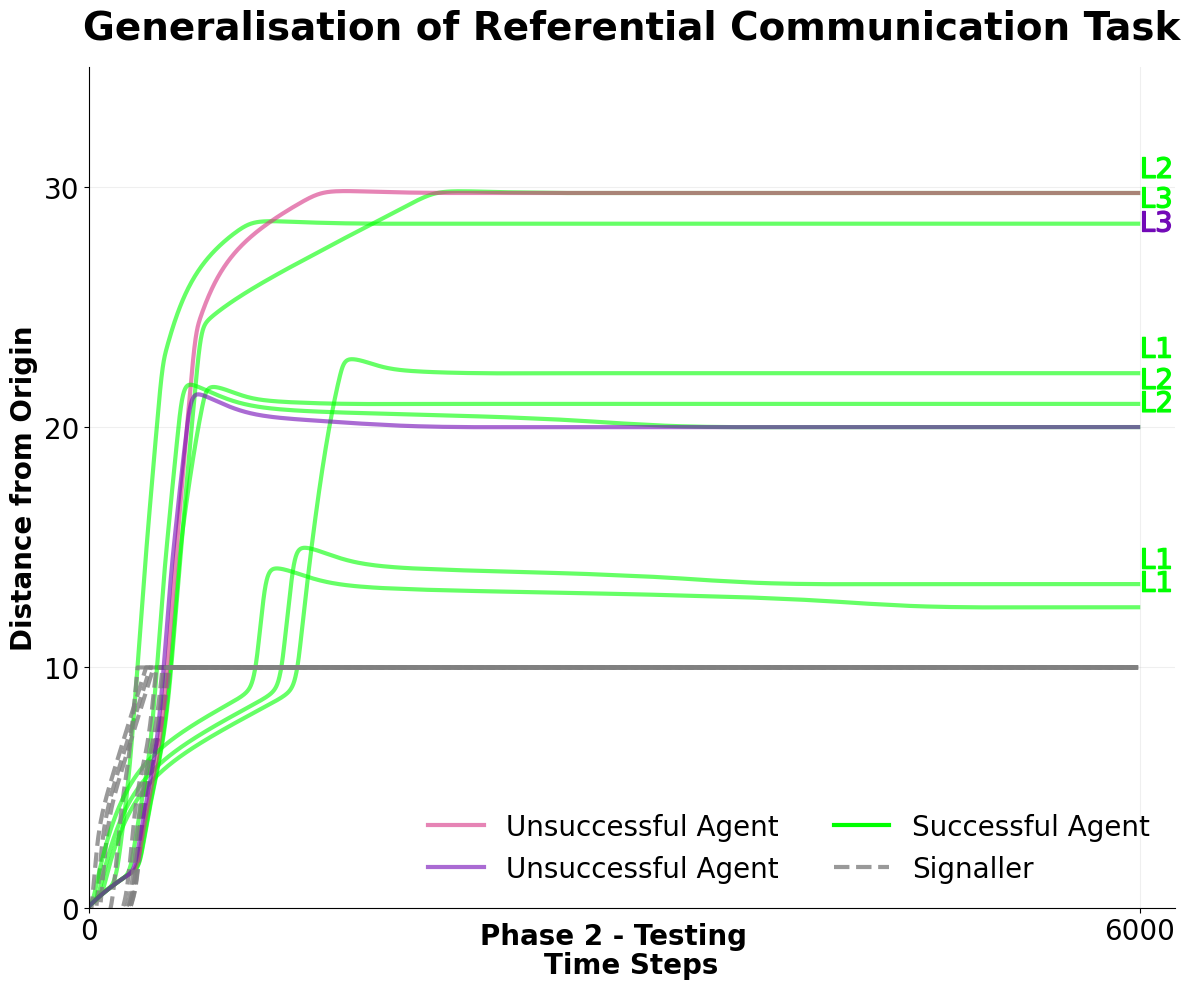

In [2]:

# the plot for a single run, batch and env with only one delay
batch = 2
run=0

# then plot phase 3 in a 3x3 grid
# fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

fig, ax = plt.subplots(figsize=(12,10))

envs = [1,2,3,1,2,3,1,2,3]
trials = [1,1,1,2,2,2,3,3,3]

colors = [
    "#7b2cbf",  # purple
    "#9d4edd",  # light purple
    "#c77dff",  # lavender
    "#ff00ff",  # magenta
    "#ff4da6",  # pink-magenta
    "#d63384",  # deep pink
    "#6a0dad",  # strong violet
    "#b5179e",  # purple-pink
    "#7209b7"   # deep purple
]

# colors = [
#     "#1f77b4", "#ff7f0e", "#2ca02c",
#     "#d62728", "#9467bd", "#17becf",
#     "#e377c2", "#bcbd22", "#8c564b"
# ]

signaller_behaviour_dir = result_dir + f"batch_{batch}/run_{run}/behavior_Signaller_stage1_{run}.dat"
receiver_behaviour_dir = result_dir + f"batch_{batch}/run_{run}/behavior_Reciever_stage1_{run}.dat"
fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{run}.dat"
landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage3_{run}.dat"

for idx in range(0, len(envs)):
    trial = trials[idx]
    env = envs[idx]

    receiver = read_ith_line(idx+1, receiver_behaviour_dir)[3010:]
    signaller = read_ith_line(idx+1, signaller_behaviour_dir)[3010:]
    fitness = read_ith_line(idx+1, fitness_file)
    landmarks = read_ith_line(idx+1, landmark_file)
    print(landmarks)

    # Get the fitness at the end of the trail
    fitness = read_ith_line(idx+1, fitness_file)
    fitness_value = fitness[len(fitness)-1]
    print(fitness_value)
    color = getColor(fitness_value)

    # Plot the signaller and reciever
    x_receiver = list(range(0, len(receiver)))
    if fitness_value >= 0.99:
        ax.plot(x_receiver, receiver, label=f"_Receiver {idx+1}", color=color, linewidth=3, alpha=0.6)
        # the landmark
        ax.scatter(len(signaller)+100,landmarks[env-1], s=400, marker=f"L${str(env)}$", zorder=3, color=color)
    else:
        ax.plot(x_receiver, receiver, label=f"Unsuccessful Agent", color=colors[idx], linewidth=3, alpha=0.6)
        # the landmark
        ax.scatter(len(signaller)+100,landmarks[env-1], s=400, marker=f"L${str(env)}$", zorder=3, color=colors[idx])


    x_signaller = list(range(0, len(signaller)))
    ax.plot(x_signaller, signaller, label=f"_Signaller {idx+1}", color="grey", linewidth=3, alpha=0.8, linestyle="dashed")

    
    # ax.axhline(y=landmarks[env-1], linestyle="--", label="food position", color=color)
ax.plot([0], [0], color=getColor(1), label="Successful Agent", linewidth=3)
ax.plot([0], [0], label=f"Signaller", color="grey", linewidth=3, alpha=0.8, linestyle="dashed")
# ax.plot([0], [0], label=f"Unsuccessful Agent", color=getColor(0.8), linewidth=3, alpha=0.8)

ax.text(len(signaller)/2,
        -1.5,
        "Phase 2 - Testing",
        ha="center", fontsize=20, fontweight="bold")

# Axes styling
# Axes styling
ax.set_ylabel("Distance from Origin", fontsize=20, fontweight="bold")
ax.set_xlabel("Time Steps", fontsize=20, fontweight="bold")

ax.tick_params(axis='both', labelsize=20)
# ax.grid(True)
# legend
# ax.legend(fontsize=20, frameon=False, ncol=3)
ax.set_title(f"Generalisation of Referential Communication Task", fontsize=28, pad=20, fontweight="bold") 
ax.grid(alpha=0.2)
ax.legend(fontsize=20, frameon=False, loc="lower right",
    ncol=2)
# remove top/right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# Colour bar
ax.set_ylim(0,35)
ax.set_xlim(0,6200)
ax.set_xticks([0, 6000])
ax.set_yticks([0, 10,20,30])

plt.tight_layout()